## Quels critères influencent réellement le prix au m² ?

## ⚙️ Régression linéaire et RandomForestRegressor

### ➡️ Importation de notre dataset

In [16]:
import pandas as pd
import numpy as np

np.long = np.int_
np.ulong = np.int64

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error

data = pd.read_csv("Data/House_Rent_Dataset_S5.csv")

# Aperçu rapide
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB
None


### ➡️ Création de la variable cible : prix au m²

In [3]:
# On retire les lignes avec Size = 0 pour éviter les divisions par zéro
data = data[data["Size"] > 0].copy()

# Prix au m²
data["price_per_m²"] = data["Rent"] / data["Size"]

# Vérification
print(data[["Rent", "Size", "price_per_m²"]].head())

    Rent  Size  price_per_m²
0  10000  1100      9.090909
1  20000   800     25.000000
2  17000  1000     17.000000
3  10000   800     12.500000
4   7500   850      8.823529


### ➡️ Préparation des variables numériques et catégorielles

In [4]:
print(f"\nValeurs manquantes par colonne:\n{data.isnull().sum()}")


Valeurs manquantes par colonne:
Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
price_per_m²         0
dtype: int64


In [5]:
# Encodage manuel avec GET_DUMMIES 
categorical_features = ['Floor', 'Area Type', 'Area Locality', 'City', 
                        'Furnishing Status', 'Tenant Preferred']
numeric_features = ['BHK', 'Bathroom']

# Nettoyage
for col in categorical_features:
    data[col] = data[col].astype(str).fillna('missing').replace('None', 'missing')

### ➡️ Split train/test et modèle de régression linéaire

In [6]:
# Création des dummies
X_encoded = pd.get_dummies(data[categorical_features], prefix=categorical_features)
X_numeric = data[numeric_features]

# Combinaison
X = pd.concat([X_encoded, X_numeric], axis=1)
y = data['price_per_m²']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### ➡️ Évaluation du modèle de régression linéaire

In [7]:
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

MSE: 2910.28
R²: -0.3040


### ➡️ Modèle avec le RandomForestRegressor

In [8]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.3384882144237278
MSE: 1476.3483724129567


### ➡️ Récupération des coefficients pour interpréter les critères

In [9]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

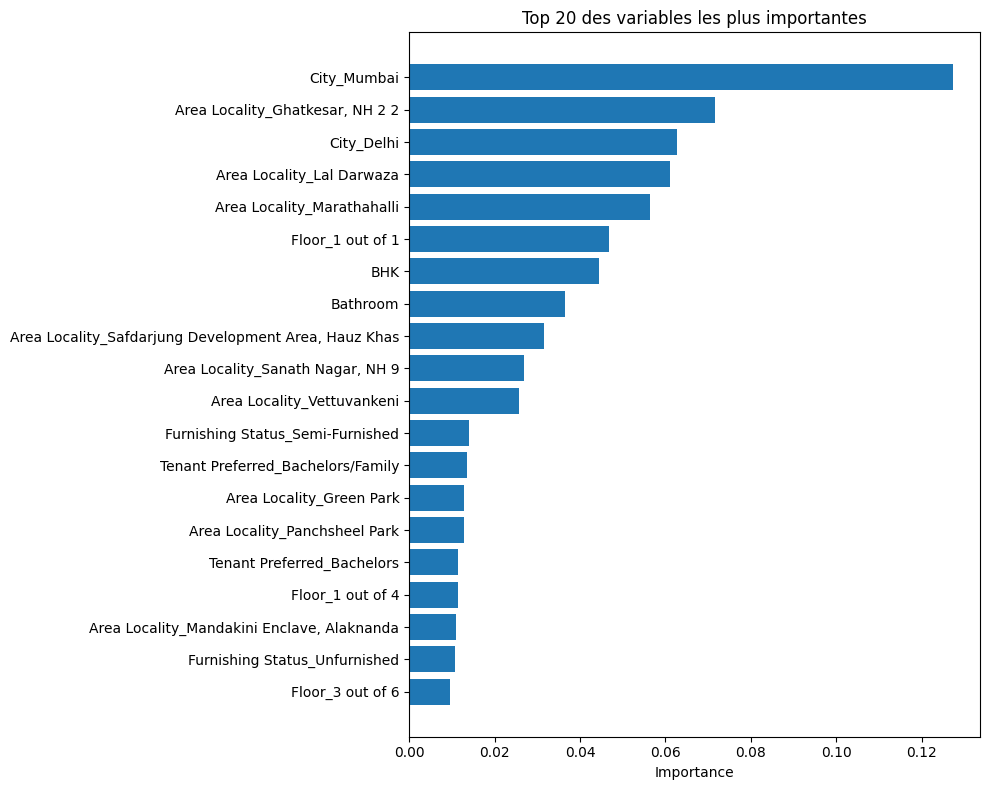

In [17]:
top20 = importance.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top20["feature"], top20["importance"])
plt.gca().invert_yaxis()  # pour avoir la plus importante en haut

plt.title("Top 20 des variables les plus importantes")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### ➡️ Résumé

Au‑delà du modèle linéaire, qui s’est révélé incapable de capturer la complexité du marché locatif, l’utilisation d’un modèle non linéaire comme le Random Forest change radicalement la lecture des données. Avec un R² de 0.338 et un MSE réduit à 1476, le modèle reste imparfait mais parvient enfin à dégager des tendances cohérentes et interprétables.

Les importances de variables montrent clairement que la localisation domine le prix au m². La ville arrive en tête, avec Mumbai et Delhi comme moteurs majeurs de variation. Mais ce sont surtout les micro‑localités (Ghatkesar, Lal Darwaza, Marathahalli, Safdarjung, Vettuvankeni…) qui pèsent lourd dans la prédiction, confirmant que le marché immobilier se joue à l’échelle du quartier, parfois même de la rue.

Les caractéristiques du logement jouent un rôle secondaire mais réel :

l’étage influence le prix,

le nombre de pièces (BHK) et de salles de bain apporte une information structurelle,

le statut du mobilier et le type de locataire recherché ont un impact plus modéré mais mesurable.

Conclusion :  Le Random Forest montre ce que la régression linéaire ne pouvait pas révéler : le marché locatif est profondément non linéaire, dominé par la géographie fine et les spécificités locales. Les modèles simples échouent à capturer cette réalité, tandis qu’un modèle plus flexible permet d’obtenir une lecture plus fidèle des critères qui façonnent le prix au m².